<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA2/TALLER4/TallerE4_SpamClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3
## Spam Classification
### Context
The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.

### Content
The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.

This corpus has been collected from free or free for research sources at the Internet:

- A collection of 425 SMS spam messages was manually extracted from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received. The identification of the text of spam messages in the claims is a very hard and time-consuming task, and it involved carefully scanning hundreds of web pages. The Grumbletext Web site is: [Web Link](http://www.grumbletext.co.uk/).
- A subset of 3,375 SMS randomly chosen ham messages of the NUS SMS Corpus (NSC), which is a dataset of about 10,000 legitimate messages collected for research at the Department of Computer Science at the National University of Singapore. The messages largely originate from Singaporeans and mostly from students attending the University. These messages were collected from volunteers who were made aware that their contributions were going to be made publicly available. The NUS SMS Corpus is avalaible at: [Web Link](http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/).
- A list of 450 SMS ham messages collected from Caroline Tag's PhD Thesis available at [Web Link](http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf).
- Finally, we have incorporated the SMS Spam Corpus v.0.1 Big. It has 1,002 SMS ham messages and 322 spam messages and it is public available at: [Web Link](http://www.esp.uem.es/jmgomez/smsspamcorpus/). This corpus has been used in the following academic researches:

Acknowledgements
The original dataset can be found [here](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection). The creators would like to note that in case you find the dataset useful, please make a reference to previous paper and the web page: http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/ in your papers, research, etc.

We offer a comprehensive study of this corpus in the following paper. This work presents a number of statistics, studies and baseline results for several machine learning methods.

Almeida, T.A., GÃ³mez Hidalgo, J.M., Yamakami, A. Contributions to the Study of SMS Spam Filtering: New Collection and Results. Proceedings of the 2011 ACM Symposium on Document Engineering (DOCENG'11), Mountain View, CA, USA, 2011.

Clasificación de Spam
Contexto
La Colección de Spam SMS es un conjunto de mensajes SMS etiquetados, recopilados para la investigación de Spam SMS. Contiene un conjunto de 5574 mensajes SMS en inglés, etiquetados según si son legítimos o spam.

Contenido
Los archivos contienen un mensaje por línea. Cada línea se compone de dos columnas: v1 contiene la etiqueta (legítimo o spam) y v2 contiene el texto sin procesar.

Este corpus se ha recopilado de fuentes gratuitas o de libre acceso para investigación en internet:

Se extrajo manualmente una colección de 425 mensajes SMS de spam del sitio web Grumbletext. Este foro del Reino Unido, donde los usuarios de teléfonos móviles publican denuncias sobre mensajes SMS de spam, la mayoría sin informar del mensaje recibido. Identificar el texto de los mensajes de spam en las denuncias es una tarea ardua y laboriosa, que implicó el análisis minucioso de cientos de páginas web. El sitio web de Grumbletext es: Enlace web.
Un subconjunto de 3375 mensajes SMS de radioaficionados, seleccionados al azar, del Corpus SMS de la NUS (NSC), un conjunto de datos de unos 10 000 mensajes legítimos recopilados para la investigación del Departamento de Informática de la Universidad Nacional de Singapur. Los mensajes provienen principalmente de singapurenses, principalmente de estudiantes de la universidad. Estos mensajes fueron recopilados por voluntarios a quienes se les informó que sus contribuciones se harían públicas. El Corpus SMS de la NUS está disponible en: Enlace web.
Una lista de 450 mensajes SMS de radioaficionados recopilados de la tesis doctoral de Caroline Tag está disponible en Enlace web. Finalmente, hemos incorporado el Corpus de Spam SMS v.0.1 Big. Contiene 1002 mensajes SMS de radioaficionados y 322 mensajes de spam, y está disponible públicamente en: Enlace web. Este corpus se ha utilizado en las siguientes investigaciones académicas:

Agradecimientos. El conjunto de datos original se encuentra aquí. Los creadores desean señalar que, si el conjunto de datos les resulta útil, les rogamos que hagan referencia a artículos anteriores y a la página web: http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/ en sus artículos, investigaciones, etc.

Ofrecemos un estudio exhaustivo de este corpus en el siguiente artículo. Este trabajo presenta diversas estadísticas, estudios y resultados de referencia para diversos métodos de aprendizaje automático.

In [1]:
!pip install wget
!pip install gensim
!pip install numpy==1.25.2

In [2]:
import pandas as pd
import numpy as np
import wget
import os
from zipfile import ZipFile
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
import gensim
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [4]:
import nltk
nltk.download('punkt')  # Tokenizador básico
nltk.download('punkt_tab')
nltk.download('stopwords')  # Lista de palabras vacías
nltk.download('wordnet')  # Lematización
nltk.download('averaged_perceptron_tagger')  # Etiquetado gramatical

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [5]:
try :
    from google.colab import files
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
    !unzip smsspamcollection.zip
    df = pd.read_csv('SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])
except ModuleNotFoundError :
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
    path = os.getcwd()+'\Data'
    wget.download(url,path)
    temp=path+'\smsspamcollection.zip'
    file = ZipFile(temp)
    file.extractall(path)
    file.close()
    df = pd.read_csv(path + '\SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])

--2025-04-23 00:03:09--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [   <=>              ] 198.65K   385KB/s    in 0.5s    

2025-04-23 00:03:10 (385 KB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
replace SMSSpamCollection? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Lee el archivo SMSSpamCollectioncomo un DataFrame con columnas:

target: Etiqueta ( ham para mensajes legítimos y spam para mensajes no deseados).

text:El contenido del mensaje.

In [7]:
display(df.shape) #Number of rows (instances) and columns in the dataset
df["target"].value_counts()/df.shape[0] #Class distribution in the dataset

(5572, 2)

,count
target,
ham,0.865937
spam,0.134063


In [8]:
X = df['text']
y = df['target'].map({'ham':0, 'spam':1})

In [9]:
# split data into training and validation set
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = df['target'], test_size = 0.3, random_state = 18)

Preprocess the text data by removing stop words, converting all text to lowercase, and removing punctuation using NLTK package.


In [10]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

Train a Word2Vec model on the preprocessed training data using Gensim package.

In [11]:
sentences = [sentence.split() for sentence in X_train]
model = Word2Vec(sentences, vector_size=100, window=5, negative=20, min_count=1, workers=4)

Convert the preprocessed text data to a vector representation using the Word2Vec model.

In [12]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test = np.array([vectorize(sentence) for sentence in X_test])

Train a classification model such as logistic regression, random forests, or support vector machines using the vectorised training data and the sentiment labels.
Entrene un modelo de clasificación como regresión logística, bosques aleatorios o máquinas de vectores de soporte utilizando los datos de entrenamiento vectorizados y las etiquetas de sentimiento.

In [13]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

Evaluate the performance of the classification model on the testing set with the accuracy, precision, recall and F1 score. Evalúe el desempeño del modelo de clasificación en el conjunto de pruebas con la precisión, exactitud, recuperación y puntuación F1.

In [14]:
#agregar metricas recall, f1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

y_pred = clf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)


print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # o 'macro', 'micro', 'weighted' según el caso
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
#print('AUC:', auc)

Accuracy: 0.8660287081339713
AUC: 0.5
Accuracy: 0.8660287081339713
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


# Excercise 3.1

Remove stopwords, then predict target using CountVectorizer.

use Random Forest classifier

Elimine las palabras vacías y luego prediga el objetivo con CountVectorizer.  Use el clasificador Random Forest.

In [15]:
# Preprocesamiento de texto: eliminación de stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

df['text_cleaned'] = df['text'].apply(remove_stopwords)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    df['text_cleaned'], df['target'], test_size=0.3, random_state=42
)

# Vectorización del texto usando CountVectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Entrenamiento del modelo RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_vec, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9784688995215312
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       1.00      0.84      0.91       224

    accuracy                           0.98      1672
   macro avg       0.99      0.92      0.95      1672
weighted avg       0.98      0.98      0.98      1672



# Excercise 3.2

Predict target using TdidfVectorizer.

use Random Forest classifier

Predecir el objetivo usando TfidfVectorizer. Usar el clasificador Random Forest.



In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorización del texto usando TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Entrenamiento del modelo RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_vec, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9796650717703349
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       1.00      0.85      0.92       224

    accuracy                           0.98      1672
   macro avg       0.99      0.92      0.95      1672
weighted avg       0.98      0.98      0.98      1672



# Excercise 3.3

Predict target using CountVectorizer or TfideVectorizer.

choose any classification model and justify why

Predecir el objetivo usando CountVectorizer o TfideVectorizer.  Elegir un modelo de clasificación y justificar el motivo.

Se utilizó TfidfVectorizer teniendo en cuenta que su logica asigna más importancia a las palabras menos comunes y más relevantes en el documento, lo que es muy eficiente para el caso que se está analizando.


Logistic Regression es el modelo de clasificación apropiado teniendo en cuenta su simplicidad y el target binario en este caso (spam ó ham).

In [17]:
# Elección del vectorizador
def vectorize_data(X_train, X_test, method='tfidf'):
    if method == 'count':
        vectorizer = CountVectorizer()
    else:
        vectorizer = TfidfVectorizer()
    return vectorizer.fit_transform(X_train), vectorizer.transform(X_test)


X_train_vec, X_test_vec = vectorize_data(X_train, X_test, method='tfidf')

# Entrenamiento del modelo Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.965311004784689
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1448
        spam       0.98      0.75      0.85       224

    accuracy                           0.97      1672
   macro avg       0.97      0.88      0.92      1672
weighted avg       0.97      0.97      0.96      1672



# Excercise 3.4

Increase and decrece the parameters values vector_size, window and negative then predict the target.

Plot the different values of the parameters with the performance of the model.

Use a Random Forest classifier and classification model of your choice and justify why.


Aumenta y disminuye los valores de los parámetros vector_size, window y negative, luego predice el objetivo.  Grafica los diferentes valores de los parámetros junto con el rendimiento del modelo.  Utiliza un clasificador Random Forest y otro modelo de clasificación de tu elección, y justifica por qué lo elegiste.

parameter variation: `vector_size`

Entrenando con vector_size=10


Entrenando con vector_size=50


Entrenando con vector_size=100


Entrenando con vector_size=150


Entrenando con vector_size=200


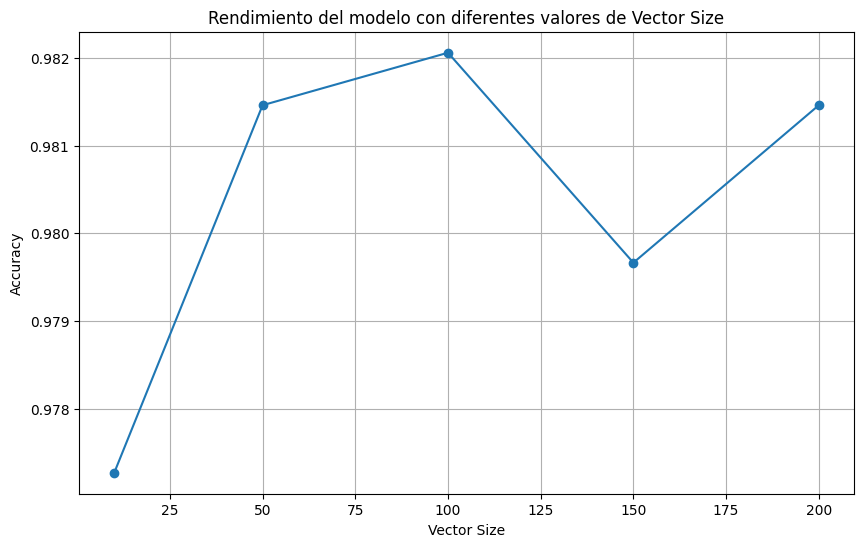

In [33]:
#Función para vectorizar
def vectorize_doc(doc, model):
    vectors = [model.wv[word] for word in doc if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Entrenamiento y evaluación del modelo
def train_and_evaluate(vector_size_values):
    results = []

    for vector_size in vector_size_values:
        print(f"Entrenando con vector_size={vector_size}")
        model_w2v = Word2Vec(sentences=X_train.tolist(), vector_size=vector_size, window=5, negative=10, sg=1, epochs=10)

        # Vectorización del texto
        X_train_vec = [vectorize_doc(doc, model_w2v) for doc in X_train]
        X_test_vec = [vectorize_doc(doc, model_w2v) for doc in X_test]

        # Entrenamiento del modelo RandomForestClassifier
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train_vec, y_train)

        # Evaluación
        y_pred = model_rf.predict(X_test_vec)
        acc = accuracy_score(y_test, y_pred)
        results.append((vector_size, acc))

    return results

#Valores para vector_size
vector_size_values = [10,50, 100, 150, 200]

#resultados
results = train_and_evaluate(vector_size_values)

#Grafica
plt.figure(figsize=(10, 6))
x = [v for v, _ in results]
y = [acc for _, acc in results]
plt.plot(x, y, marker='o')

plt.title('Rendimiento del modelo con diferentes valores de Vector Size')
plt.xlabel('Vector Size')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

parameter variation: `window`

Entrenando Word2Vec con window = 2
Accuracy para window=2: 0.9779
Entrenando Word2Vec con window = 5
Accuracy para window=5: 0.9773
Entrenando Word2Vec con window = 10
Accuracy para window=10: 0.9827
Entrenando Word2Vec con window = 15
Accuracy para window=15: 0.9791
Entrenando Word2Vec con window = 20
Accuracy para window=20: 0.9803


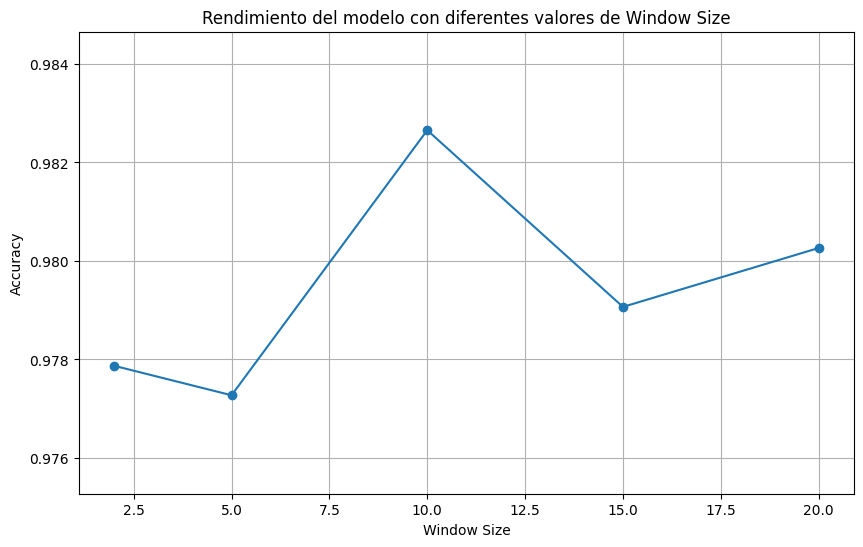

In [23]:
# Función para tokenizar
def tokenize(text):
    return text.lower().split()

# Entrenamiento y evaluación del modelo
def train_and_evaluate_window(window_values, vector_size=100):
    results = []

    # Tokenizar los datos
    X_train_tokenized = [tokenize(text) for text in X_train]
    X_test_tokenized = [tokenize(text) for text in X_test]

    for window in window_values:
        print(f"Entrenando Word2Vec con window = {window}")

        # Entrenar Word2Vec
        model_w2v = Word2Vec(
            sentences=X_train_tokenized,
            vector_size=vector_size,
            window=window,
            negative=10,
            sg=1,
            epochs=20
        )

        # Vectorización
        def vectorize(doc):
            vectors = [model_w2v.wv[word] for word in doc if word in model_w2v.wv]
            return sum(vectors) / len(vectors) if vectors else [0.0] * model_w2v.vector_size

        X_train_vec = [vectorize(doc) for doc in X_train_tokenized]
        X_test_vec = [vectorize(doc) for doc in X_test_tokenized]

        # Ajustar tamaño
        min_len = min(len(X_train_vec), len(y_train))
        X_train_vec = X_train_vec[:min_len]
        y_train_trimmed = y_train[:min_len]

        # Entrenamiento y evaluación
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train_vec, y_train_trimmed)
        y_pred = model_rf.predict(X_test_vec)
        acc = accuracy_score(y_test[:len(y_pred)], y_pred)

        print(f"Accuracy para window={window}: {acc:.4f}")
        results.append((window, acc))

    return results

#Valores para window
window_values = [2,5, 10, 15, 20]

#Resultados
results_window = train_and_evaluate_window(window_values)

# Graficar resultados
plt.figure(figsize=(10, 6))
x = [w for w, _ in results_window]
y = [acc for _, acc in results_window]
plt.plot(x, y, marker='o')
plt.title('Rendimiento del modelo con diferentes valores de Window Size')
plt.xlabel('Window Size')
plt.ylabel('Accuracy')
plt.ylim(min(y) - 0.002, max(y) + 0.002)
plt.grid(True)
plt.show()

parameter variation: `negative`

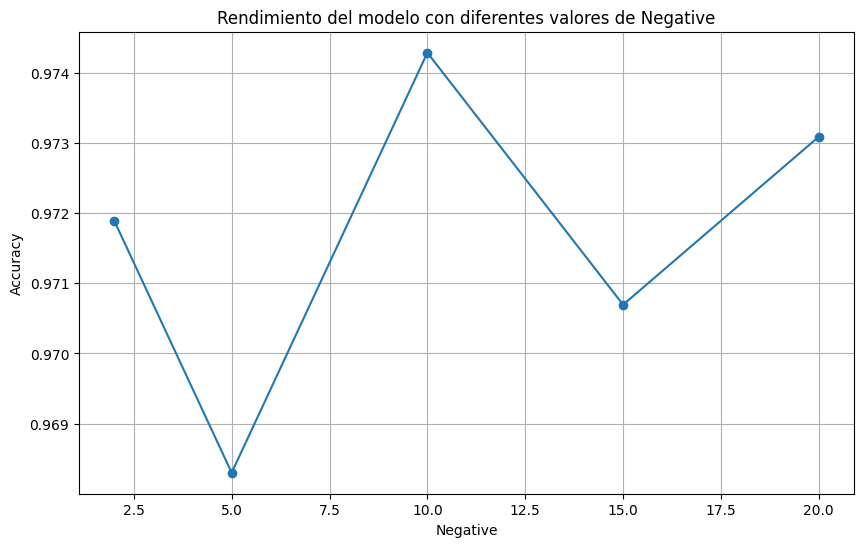

In [28]:
def train_and_evaluate_negative(negative_values):
    results = []

    X_train_tokenized = [tokenize(text) for text in X_train]
    X_test_tokenized = [tokenize(text) for text in X_test]

    for negative in negative_values:
        model_w2v = Word2Vec(sentences=X_train_tokenized, vector_size=100, window=5, negative=negative, sg=1)


        def get_vector(doc):
            vectors = [model_w2v.wv[word] for word in doc if word in model_w2v.wv]
            return sum(vectors) / len(vectors) if vectors else [0.0] * model_w2v.vector_size

        # Vectorización
        X_train_vec = [get_vector(doc) for doc in X_train_tokenized]
        X_test_vec = [get_vector(doc) for doc in X_test_tokenized]

        # Modelo Clasificación
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train_vec, y_train)

        y_pred = model_rf.predict(X_test_vec)
        acc = accuracy_score(y_test, y_pred)
        results.append((negative, acc))

    return results
# Valores para negative
negative_values = [2, 5, 10, 15, 20]

#Resultados
results = train_and_evaluate_negative(negative_values)

# Graficar resultados
plt.figure(figsize=(10, 6))
x = [v for v, _ in results]
y = [acc for _, acc in results]
plt.plot(x, y, marker='o')

plt.title('Rendimiento del modelo con diferentes valores de Negative')
plt.xlabel('Negative')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

Running best parameters `vector_size, window and negative` (All at the same time)

In [35]:
# Entrenar modelo Word2Vec con mejores parámetros
model_w2v = Word2Vec(
    sentences=X_train_tokenized,
    vector_size=100,
    window=10,
    negative=10,
    sg=1
)

# Vectorización
X_train_vectors = np.array([
    np.mean([model_w2v.wv[word] for word in words if word in model_w2v.wv] or [np.zeros(100)], axis=0)
    for words in X_train_tokenized
])

X_test_vectors = np.array([
    np.mean([model_w2v.wv[word] for word in words if word in model_w2v.wv] or [np.zeros(100)], axis=0)
    for words in X_test_tokenized
])

# Entrenar y evaluar el clasificador
clf = LogisticRegression()
clf.fit(X_train_vectors, y_train)
y_pred = clf.predict(X_test_vectors)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy con mejores parámetros (vector_size=100, window=10, negative=10): {accuracy:.4f}")


Accuracy con mejores parámetros (vector_size=100, window=10, negative=10): 0.9456


In [36]:
X_train_tokenized = [tokenize(text) for text in X_train]
X_test_tokenized = [tokenize(text) for text in X_test]

model_w2v = Word2Vec(
    sentences=X_train_tokenized,
    vector_size=100,
    window=10,
    negative=10,
    sg=1
)

# Vectorización
X_train_vectors = np.array([
    np.mean([model_w2v.wv[word] for word in words if word in model_w2v.wv] or [np.zeros(100)], axis=0)
    for words in X_train_tokenized
])

X_test_vectors = np.array([
    np.mean([model_w2v.wv[word] for word in words if word in model_w2v.wv] or [np.zeros(100)], axis=0)
    for words in X_test_tokenized
])

# Entrenar y evaluar el clasificador Logistic Regression
clf_log_reg = LogisticRegression()
clf_log_reg.fit(X_train_vectors, y_train)
y_pred_log_reg = clf_log_reg.predict(X_test_vectors)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

# Entrenar y evaluar el clasificador Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_vectors, y_train)
y_pred_rf = clf_rf.predict(X_test_vectors)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Imprimir los resultados de ambos clasificadores
print(f"Accuracy con Logistic Regression: {accuracy_log_reg:.4f}")
print(f"Accuracy con Random Forest: {accuracy_rf:.4f}")


Accuracy con Logistic Regression: 0.9462
Accuracy con Random Forest: 0.9719


Se eligió el modelo de Regresión Logística teniendo en cuenta que es muy acertado para este caso con un target binario (spam o ham), y complementa la vectorización que realiza word2vec.

Los mejores parámetros fueron los siguientes:

vector_size:150
window: 10
negative: 10